# Extract hospitals and roads

Download hospital locations and the road network from OpenStreetMap for the Nairobi study area, save them as reusable processed artifacts, and create quick diagnostic maps for downstream accessibility analysis.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    CRS_PROJECTED,
    FILES,
    ensure_project_dirs,
    get_bbox_gdf,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Nairobi
BBOX: {'lon_min': 36.6, 'lat_min': -1.5, 'lon_max': 37.1, 'lat_max': -1.1}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/hrsl_kenya.tif


In [2]:
bbox_gdf = get_bbox_gdf()
bbox_gdf

,city,geometry
0,Nairobi,"POLYGON ((37.1 -1.5, 37.1 -1.1, 36.6 -1.1, 36...."


In [3]:
north = bbox_gdf.total_bounds[3]
south = bbox_gdf.total_bounds[1]
east = bbox_gdf.total_bounds[2]
west = bbox_gdf.total_bounds[0]

print("North:", north)
print("South:", south)
print("East :", east)
print("West :", west)

North: -1.1
South: -1.5
East : 37.1
West : 36.6


In [6]:
tags = {"amenity": True}

bbox = (west, south, east, north)

features = ox.features_from_bbox(bbox, tags=tags)

hospitals = features[
    features["amenity"].astype(str).str.lower() == "hospital"
].copy()

print("Raw hospital features:", len(hospitals))
hospitals.head()

Raw hospital features: 328


geometry addr:housenumber   amenity  \
element id                                                                
node    275554473  POINT (36.81197 -1.26377)              NaN  hospital   
        612007438  POINT (36.78605 -1.30787)              NaN  hospital   
        612007453   POINT (36.78633 -1.3072)              NaN  hospital   
        612007456  POINT (36.78882 -1.30723)              NaN  hospital   
        612007539  POINT (36.77823 -1.31793)              NaN  hospital   

                  denomination                        name religion addr:city  \
element id                                                                      
node    275554473          NaN         M. P. Shah Hospital      NaN       NaN   
        612007438          NaN        Upendo Vision Clinic      NaN       NaN   
        612007453          NaN           New Makina Clinic      NaN       NaN   
        612007456          NaN  St Augustus Medical Clinic      NaN       NaN   
        612007539          NaN                 Wema Clinic      NaN       NaN   

                  addr:street brand brand:wikidata  ... language:fr  \
element id                                          ...               
node    275554473         NaN   NaN            NaN  ...         NaN   
        612007438         NaN   NaN            NaN  ...         NaN   
        612007453         NaN   NaN            NaN  ...         NaN   
        612007456         NaN   NaN            NaN  ...         NaN   
        612007539         NaN   NaN            NaN  ...         NaN   

                  manufacturer tram diet:lactose_free orientation  \
element id                                                          
node    275554473          NaN  NaN               NaN         NaN   
        612007438          NaN  NaN               NaN         NaN   
        612007453          NaN  NaN               NaN         NaN   
        612007456          NaN  NaN               NaN         NaN   
        612007539          NaN  NaN               NaN         NaN   

                  theatre:type resort short_name:en bridge maxweight:signed  
element id                                                                   
node    275554473          NaN    NaN           NaN    NaN              NaN  
        612007438          NaN    NaN           NaN    NaN              NaN  
        612007453          NaN    NaN           NaN    NaN              NaN  
        612007456          NaN    NaN           NaN    NaN              NaN  
        612007539          NaN    NaN           NaN    NaN              NaN  

[5 rows x 765 columns]

In [7]:
hospitals = hospitals.reset_index()

# Keep only valid geometries
hospitals = hospitals[
    hospitals.geometry.type.isin(["Point", "Polygon", "MultiPolygon"])
].copy()

# Convert polygons → centroids
hospitals = hospitals.to_crs(CRS_PROJECTED)
hospitals["geometry"] = hospitals.geometry.centroid

# Keep useful columns only
keep_cols = [col for col in hospitals.columns if col in [
    "osmid",
    "name",
    "amenity",
    "healthcare",
    "operator",
    "geometry"
]]

hospitals = hospitals[keep_cols].copy()

# Drop duplicates
hospitals = hospitals.drop_duplicates(subset=["geometry"]).reset_index(drop=True)

print("Processed hospital features:", len(hospitals))
hospitals.head()

Processed hospital features: 326


,geometry,amenity,name,operator,healthcare
0,POINT (4097889.577 -140694.165),hospital,M. P. Shah Hospital,NaN,hospital
1,POINT (4095004.399 -145603.889),hospital,Upendo Vision Clinic,NaN,hospital
2,POINT (4095035.424 -145529.286),hospital,New Makina Clinic,NaN,hospital
3,POINT (4095313.043 -145532.838),hospital,St Augustus Medical Clinic,NaN,hospital
4,POINT (4094134.292 -146723.946),hospital,Wema Clinic,NaN,hospital


In [9]:
if FILES["roads_graphml"].exists():
    roads = ox.load_graphml(FILES["roads_graphml"])
    print("Loaded road graph from file:", FILES["roads_graphml"])
else:
    bbox = (west, south, east, north)
    roads = ox.graph_from_bbox(
        bbox,
        network_type="drive",
        simplify=True
    )
    ox.save_graphml(roads, FILES["roads_graphml"])
    print("Downloaded and saved road graph to:", FILES["roads_graphml"])

print("Nodes:", len(roads.nodes))
print("Edges:", len(roads.edges))

Downloaded and saved road graph to: /Users/suvo/Projects/urban-healthcare/data/processed/roads.graphml
Nodes: 86640
Edges: 212368


In [10]:
ox.save_graphml(roads, FILES["roads_graphml"])
print("Saved road graph to:", FILES["roads_graphml"])

Saved road graph to: /Users/suvo/Projects/urban-healthcare/data/processed/roads.graphml


In [11]:
hospitals.to_parquet(FILES["hospitals"], index=False)
print("Saved hospitals to:", FILES["hospitals"])

Saved hospitals to: /Users/suvo/Projects/urban-healthcare/data/processed/hospitals.parquet


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/04_nairobi_hospitals.png


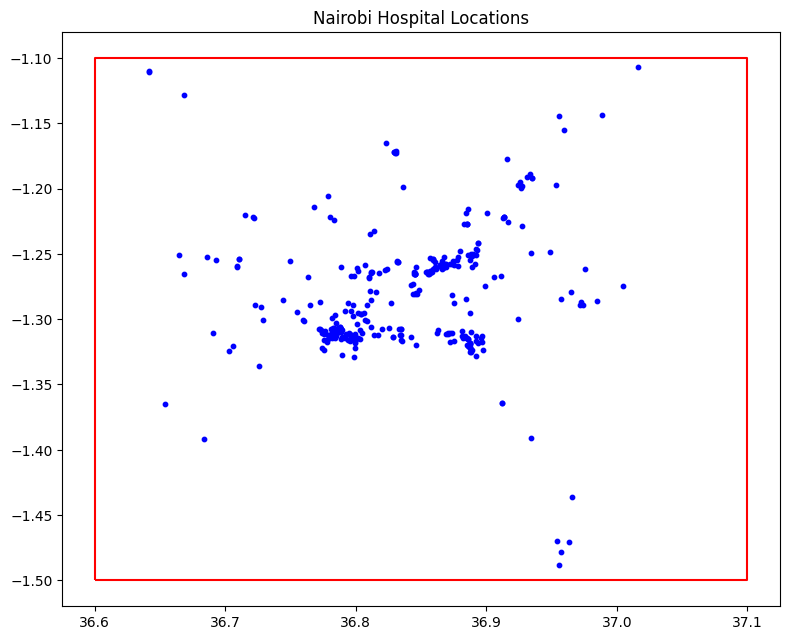

In [12]:
hospitals_wgs84 = hospitals.to_crs(CRS_WGS84)

fig, ax = plt.subplots(figsize=(8, 8))
bbox_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
hospitals_wgs84.plot(ax=ax, color="blue", markersize=10)

ax.set_title(f"{CITY_NAME} Hospital Locations")
plt.tight_layout()

savefig(fig, "04_nairobi_hospitals.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/04_nairobi_roads.png


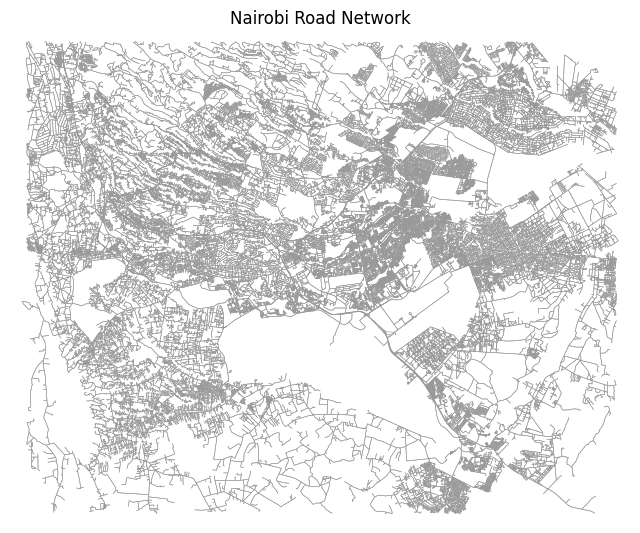

In [13]:
fig, ax = ox.plot_graph(
    roads,
    figsize=(8, 8),
    node_size=0,
    edge_linewidth=0.4,
    bgcolor="white",
    show=False,
    close=False
)

ax.set_title(f"{CITY_NAME} Road Network")

savefig(fig, "04_nairobi_roads.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/04_nairobi_hospitals_roads.png


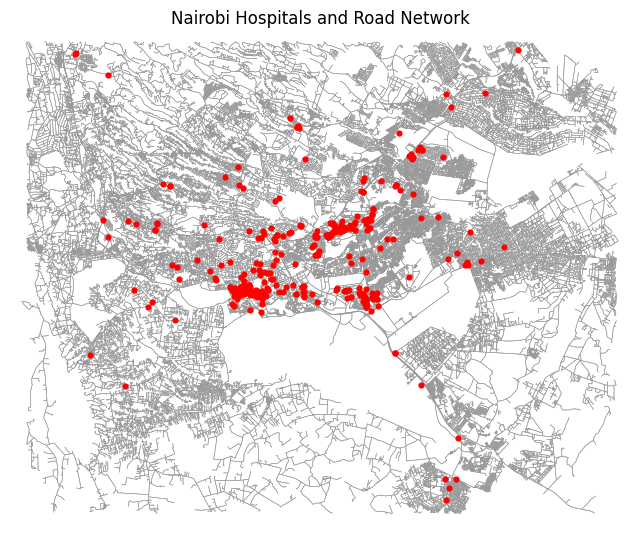

In [14]:
# Convert hospitals to same CRS as graph
hospitals_proj = hospitals.to_crs(ox.graph_to_gdfs(roads, nodes=False).crs)

fig, ax = ox.plot_graph(
    roads,
    figsize=(8, 8),
    node_size=0,
    edge_linewidth=0.4,
    bgcolor="white",
    show=False,
    close=False
)

hospitals_proj.plot(ax=ax, color="red", markersize=12)

ax.set_title(f"{CITY_NAME} Hospitals and Road Network")

savefig(fig, "04_nairobi_hospitals_roads.png")
plt.show()